# Task 5 – Uncertainty Evaluation

 - A ResNet18 model with dropout is evaluated using MC Dropout, where the model is run multiple times and the variation in predictions is used to estimate uncertainty.

- Dropout is applied in the network and before the final layer. During MC inference, dropout is kept active so the model can produce different predictions for the same input.

- Uncertainty is measured using entropy and variance, and evaluated using plots, a statistical test, and a triage curve.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy.stats import mannwhitneyu
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,f1_score, cohen_kappa_score,)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms


## Load Data


In [2]:
# Paths to data
train_images_folder = 'Data/Training/Training_Images'
train_csv           = 'Data/Training/Training_LabelsDemographic.csv'
test_images_folder  = 'Data/Testing/Testing_Images'
test_csv            = 'Data/Testing/Testing_LabelDemographic.csv'

# Load labels
train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

print('Training samples:', len(train_df))
print('Test samples:    ', len(test_df))
train_df.head()

Training samples: 1143
Test samples:     248


,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_train_0001.png,0,51,male,183.5,78.9,1
1,mmac_task_1_train_0002.png,0,51,male,183.5,78.9,1
2,mmac_task_1_train_0003.png,0,50,male,184.5,81.7,1
3,mmac_task_1_train_0004.png,0,50,male,184.5,81.7,1
4,mmac_task_1_train_0005.png,0,49,male,184.5,82.2,1


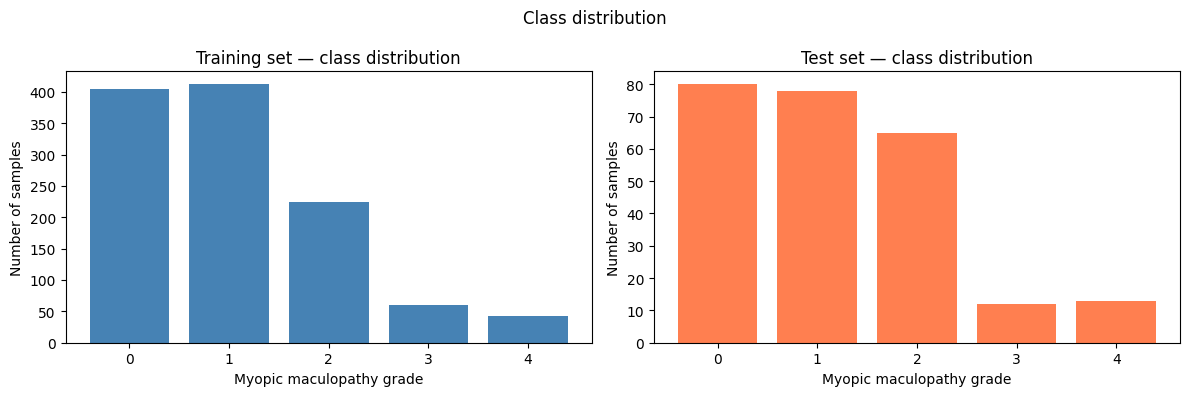

In [3]:
# Class distribution of dataset to identify imbalance
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
test_counts = test_df["myopic_maculopathy_grade"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set
axes[0].bar(class_counts.index, class_counts.values, color="steelblue")
axes[0].set_xlabel("Myopic maculopathy grade")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Training set — class distribution")
axes[0].set_xticks(class_counts.index)

# Test set
axes[1].bar(test_counts.index, test_counts.values, color="coral")
axes[1].set_xlabel("Myopic maculopathy grade")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Test set — class distribution")
axes[1].set_xticks(test_counts.index)

plt.suptitle("Class distribution", fontsize=12)
plt.tight_layout()
plt.show()


In [4]:
# Demographic statistics to identify potential sources of bias in the dataset.
age_summary = pd.DataFrame({"Metric": ["Age (mean)", "Age (std)", "Age (min)", "Age (max)"],
    "Value": [train_df["age"].mean(), train_df["age"].std(), train_df["age"].min(), train_df["age"].max() ]})

display(age_summary)

# Sex distribution table
sex_summary = train_df["sex"].value_counts().rename_axis("Sex").reset_index(name="Count")
display(sex_summary)

# Data centre distribution table
centre_summary = train_df["data_center"].value_counts().rename_axis("Data centre").reset_index(name="Count")
display(centre_summary)


,Metric,Value
0,Age (mean),53.846019
1,Age (std),10.498641
2,Age (min),29.000000
3,Age (max),93.000000


,Sex,Count
0,male,697
1,female,293


,Data centre,Count
0,1,990
1,2,153


## Data transformation


In [5]:
# Image preprocessing (RGB)
transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


In [6]:
# Custom dataset to load images and corresponding labels
class MMACDataset(Dataset):
    """Custom dataset for MMAC retinal images."""
    def __init__(self, df, images_folder, transform=None):
        self.df            = df.reset_index(drop=True)
        self.images_folder = images_folder
        self.transform     = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        image_name = row['image']
        label      = int(row['myopic_maculopathy_grade'])
        image_path = os.path.join(self.images_folder, image_name)
        image      = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {'image': image,
                'label': torch.tensor(label, dtype=torch.long),
                'image_name': image_name}


## Train / validation

The data is split into 80% training and 20% validation, keeping all classes represented in both sets. The validation set is used for calibration.


In [7]:
# Train/validation split
train_idx, val_idx = train_test_split( np.arange(len(train_df)),
                     test_size=0.2, stratify=train_df['myopic_maculopathy_grade'].values, random_state=42)

full_train_dataset = MMACDataset(train_df, train_images_folder, transform=transform)
test_dataset = MMACDataset(test_df, test_images_folder, transform=transform)

train_subset = Subset(full_train_dataset, train_idx)
val_subset   = Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")


Train: 914 | Val: 229 | Test: 248


## ResNet18 with dropout

Dropout is added in different parts  not just the final layer, so MC Dropout captures more uncertainty. During inference  dropout is kept active while the rest of the model stays in evaluation mode.

In [ ]:
class ResNet18Dropout(nn.Module):
    """ ResNet18 with dropout inside the backbone and before the final classification layer."""
    def __init__(self, num_classes=5, dropout_p=0.3):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # split the backbone
        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.avgpool = backbone.avgpool

        # standard MC Dropout placement for CNNs
        self.drop2 = nn.Dropout2d(p=dropout_p)
        self.drop3 = nn.Dropout2d(p=dropout_p)
        self.drop4 = nn.Dropout2d(p=dropout_p)

        in_features = backbone.fc.in_features
        self.classifier = nn.Sequential(nn.Dropout(p=dropout_p), nn.Linear(in_features, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.drop2(x)
        x = self.layer3(x)
        x = self.drop3(x)
        x = self.layer4(x)
        x = self.drop4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def enable_dropout(model):
    """Switch only dropout layers to training mode. BatchNorm stays in eval mode so only dropout is stochastic."""
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## Training


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    """Evaluate model with dropout disabled."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


In [10]:
## training loop
model     = ResNet18Dropout(num_classes=5, dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 24
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

MODEL_PATH = 'task5_resnet18_dropout.pth'

# Load saved weights if available, otherwise train from scratch
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print('Loaded saved model from', MODEL_PATH)
else:
    print('Training model...')
    for epoch in tqdm(range(num_epochs), desc='Training'):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        train_losses.append(t_loss);  train_accs.append(t_acc)
        val_losses.append(v_loss);    val_accs.append(v_acc)
        print(f'Epoch {epoch+1}/{num_epochs} — '
              f'Train loss: {t_loss:.4f}, acc: {t_acc:.4f} | '
              f'Val loss: {v_loss:.4f}, acc: {v_acc:.4f}')
    torch.save(model.state_dict(), MODEL_PATH)
    print('Model saved to', MODEL_PATH)


Training model...


Training:   4%|▍         | 1/24 [09:31<3:39:10, 571.75s/it]

Epoch 1/24 — Train loss: 1.3813, acc: 0.4442 | Val loss: 0.6282, acc: 0.7424


Training:   8%|▊         | 2/24 [10:40<1:41:09, 275.87s/it]

Epoch 2/24 — Train loss: 0.9099, acc: 0.6302 | Val loss: 0.5081, acc: 0.7904


...

Training:  96%|█████████▌| 23/24 [37:56<01:23, 83.78s/it]

Epoch 23/24 — Train loss: 0.1346, acc: 0.9562 | Val loss: 0.4892, acc: 0.8821


Training: 100%|██████████| 24/24 [39:12<00:00, 98.00s/it]

Epoch 24/24 — Train loss: 0.1069, acc: 0.9672 | Val loss: 0.5059, acc: 0.8734


Model saved to task5_resnet18_dropout.pth


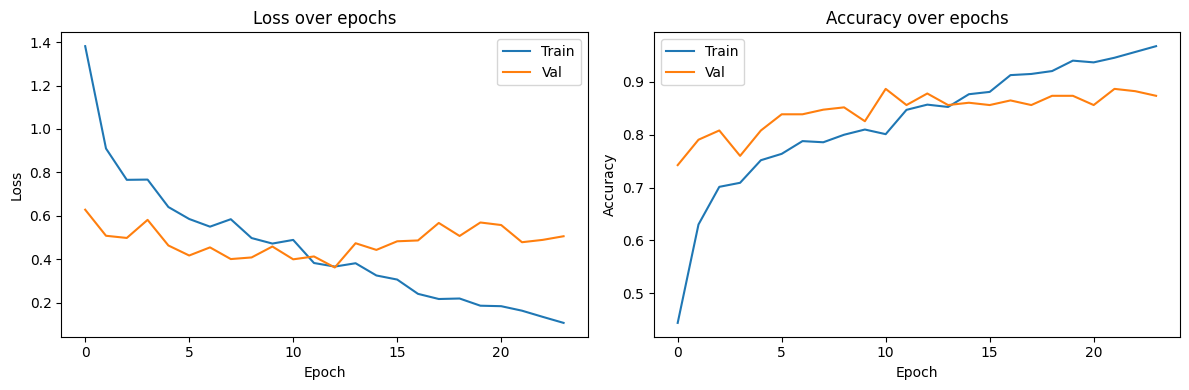

In [11]:
# Plot training and validation curves
if train_losses:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over epochs'); axes[0].legend()
    axes[1].plot(train_accs, label='Train'); axes[1].plot(val_accs, label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy over epochs'); axes[1].legend()
    plt.tight_layout(); plt.show()

## MC Dropout inference
The model is run multiple times with dropout active, and the variation in predictions is used to estimate uncertainty. Uncertainty is measured using entropy and separated into aleatoric (data) and epistemic (model) components.

In [12]:
def mc_dropout_inference(model, images, T=30):
    model.eval()           
    enable_dropout(model)  
    preds = []

    with torch.no_grad():
        for _ in range(T):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds.append(probs)

    preds = torch.stack(preds)          # (T, B, C)
    mean_pred = preds.mean(dim=0)       # (B, C)

    # Variance across passes
    variance = preds.var(dim=0).mean(dim=1)
    # Total predictive uncertainty (entropy of mean)
    total_entropy = -(mean_pred * torch.log(mean_pred + 1e-8)).sum(dim=1)
    # Aleatoric uncertainty (mean of per-pass entropies)
    per_pass_entropy = -(preds * torch.log(preds + 1e-8)).sum(dim=2)   # (T, B)
    aleatoric = per_pass_entropy.mean(dim=0)                           # (B,)
    # Epistemic uncertainty (mutual information = total - aleatoric)
    epistemic = total_entropy - aleatoric

    return mean_pred, variance, total_entropy, aleatoric, epistemic


## Evaluation on the test set


In [13]:
# For each image, the predicted label, confidence, uncertainty measures, and correctness are stored.
all_true, all_pred, all_conf = [], [], []
all_variance  = []
all_entropy   = []
all_aleatoric = []
all_epistemic = []
all_correct   = []
all_names     = []
all_probs     = []  # keep full mean-prediction vector for calibration

for batch in tqdm(test_loader, desc="MC Dropout evaluation (T=30)"):
    images = batch["image"].to(device)
    labels = batch["label"].to(device)
    image_names = batch["image_name"]

    mean_pred, variance, entropy, aleatoric, epistemic = mc_dropout_inference(model, images, T=30)

    preds = torch.argmax(mean_pred, dim=1)
    conf = mean_pred.max(dim=1).values

    all_true.extend(labels.cpu().numpy())
    all_pred.extend(preds.cpu().numpy())
    all_conf.extend(conf.cpu().numpy())
    all_variance.extend(variance.cpu().numpy())
    all_entropy.extend(entropy.cpu().numpy())
    all_aleatoric.extend(aleatoric.cpu().numpy())
    all_epistemic.extend(epistemic.cpu().numpy())
    all_correct.extend((preds == labels).cpu().numpy())
    all_names.extend(image_names)
    all_probs.append(mean_pred.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

results_df = pd.DataFrame({
    "image_name": all_names,
    "true_label": all_true,
    "pred_label": all_pred,
    "confidence": all_conf,
    "variance": all_variance,
    "entropy": all_entropy,
    "aleatoric": all_aleatoric,
    "epistemic": all_epistemic,
    "correct": all_correct,})

accuracy = results_df["correct"].mean()
macro_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
qkappa   = cohen_kappa_score(all_true, all_pred, weights='quadratic')

print(f"Test accuracy:   {accuracy:.4f} ({results_df['correct'].sum()}/{len(results_df)})")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Quadratic kappa: {qkappa:.4f}")

results_df.head()


MC Dropout evaluation (T=30): 100%|██████████| 16/16 [04:48<00:00, 18.01s/it]

Test accuracy:   0.7944 (197/248)
Macro F1:        0.7295
Quadratic kappa: 0.8275


,image_name,true_label,pred_label,confidence,variance,entropy,aleatoric,epistemic,correct
0,mmac_task_1_val_0001.png,3,2,0.667196,0.037331,0.879451,0.551627,0.327824,False
1,mmac_task_1_val_0002.png,3,1,0.614474,0.031446,0.704022,0.516708,0.187314,False
2,mmac_task_1_val_0003.png,2,2,0.531343,0.042508,0.804058,0.537964,0.266095,True
3,mmac_task_1_val_0004.png,2,2,0.991038,0.000057,0.060383,0.051707,0.008676,True
4,mmac_task_1_val_0005.png,2,2,0.992620,0.000035,0.051052,0.044579,0.006473,True


In [14]:
# Mean uncertainty for correct vs incorrect predictions
correct_df = results_df[results_df["correct"]]
incorrect_df = results_df[~results_df["correct"]]

summary = pd.DataFrame({"Metric": ["Total entropy", "Aleatoric", "Epistemic", "Variance", "Confidence"],
    "Correct": [
        correct_df["entropy"].mean(),
        correct_df["aleatoric"].mean(),
        correct_df["epistemic"].mean(),
        correct_df["variance"].mean(),
        correct_df["confidence"].mean()],
    "Incorrect": [
        incorrect_df["entropy"].mean(),
        incorrect_df["aleatoric"].mean(),
        incorrect_df["epistemic"].mean(),
        incorrect_df["variance"].mean(),
        incorrect_df["confidence"].mean() ], }).round(6)

display(summary)


,Metric,Correct,Incorrect
0,Total entropy,0.292463,0.549855
1,Aleatoric,0.212445,0.397320
2,Epistemic,0.080019,0.152535
3,Variance,0.008389,0.018153
4,Confidence,0.895339,0.786337


## Confusion matrix
The confusion matrix shows how predictions are distributed across classes.


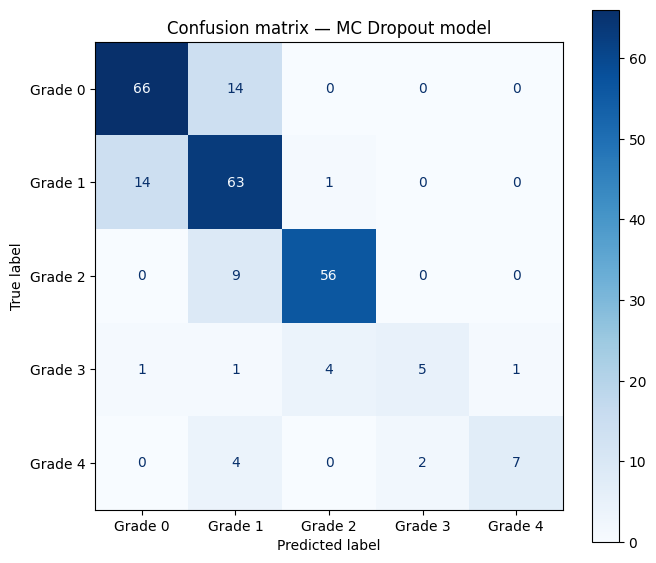

              precision    recall  f1-score   support

     Grade 0       0.81      0.82      0.82        80
     Grade 1       0.69      0.81      0.75        78
     Grade 2       0.92      0.86      0.89        65
     Grade 3       0.71      0.42      0.53        12
     Grade 4       0.88      0.54      0.67        13

    accuracy                           0.79       248
   macro avg       0.80      0.69      0.73       248
weighted avg       0.80      0.79      0.79       248



In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(results_df["true_label"], results_df["pred_label"])
disp = ConfusionMatrixDisplay(cm, display_labels=[f"Grade {i}" for i in range(5)])
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title("Confusion matrix — MC Dropout model")

plt.tight_layout()
plt.show()

print(classification_report(all_true, all_pred,
      target_names=[f"Grade {i}" for i in range(5)], zero_division=0))


## Uncertainty distributions
Uncertainty is compared between correct and incorrect predictions using entropy and the epistemic component.

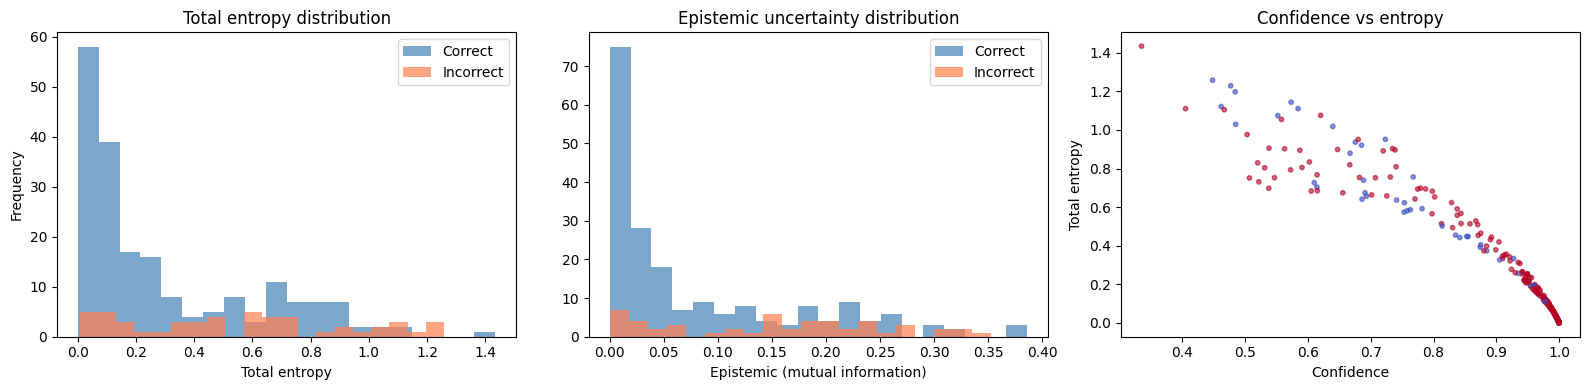

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total entropy histogram
axes[0].hist(correct_df["entropy"], bins=20, alpha=0.7, label="Correct", color="steelblue")
axes[0].hist(incorrect_df["entropy"], bins=20, alpha=0.7, label="Incorrect", color="coral")
axes[0].set_xlabel("Total entropy")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Total entropy distribution")
axes[0].legend()

# Epistemic uncertainty histogram
axes[1].hist(correct_df["epistemic"], bins=20, alpha=0.7, label="Correct", color="steelblue")
axes[1].hist(incorrect_df["epistemic"], bins=20, alpha=0.7, label="Incorrect", color="coral")
axes[1].set_xlabel("Epistemic (mutual information)")
axes[1].set_title("Epistemic uncertainty distribution")
axes[1].legend()

# Confidence vs entropy
axes[2].scatter(results_df["confidence"], results_df["entropy"], c=results_df["correct"].astype(int), cmap="coolwarm", alpha=0.6, s=10)
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Total entropy")
axes[2].set_title("Confidence vs entropy")

plt.tight_layout()
plt.show()


## Statistical test (entropy: correct vs incorrect)
A Mann-Whitney U test is used to compare entropy between correct and incorrect predictions.


In [17]:
u_stat, p_val = mannwhitneyu(correct_df['entropy'], incorrect_df['entropy'], alternative='two-sided')
print(f'Total entropy:   U = {u_stat:.1f}, p = {p_val:.4e}')
print('  ->', 'Significant difference' if p_val < 0.05 else 'No significant difference')

u_stat_e, p_val_e = mannwhitneyu(correct_df['epistemic'], incorrect_df['epistemic'], alternative='two-sided')
print(f'Epistemic:       U = {u_stat_e:.1f}, p = {p_val_e:.4e}')
print('  ->', 'Significant difference' if p_val_e < 0.05 else 'No significant difference')


Total entropy:   U = 2991.0, p = 8.5721e-06
  -> Significant difference
Epistemic:       U = 2950.0, p = 5.6209e-06
  -> Significant difference


## Uncertainty by grade
Uncertainty is plotted by grade to see if some grades are more uncertain than others.

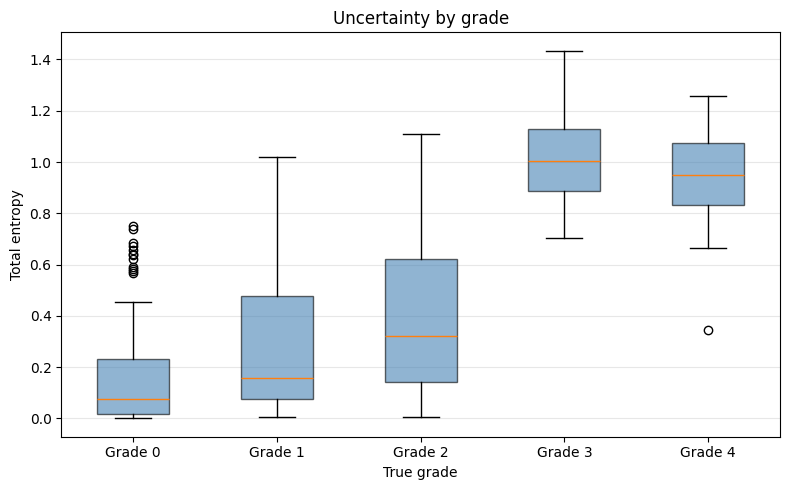

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [results_df[results_df['true_label'] == g]['entropy'].values for g in range(5)],
    patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_xticklabels([f'Grade {g}' for g in range(5)])
ax.set_xlabel('True grade')
ax.set_ylabel('Total entropy')
ax.set_title('Uncertainty by grade')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Calibration
Calibration checks if predicted confidence matches accuracy. This is evaluated using ECE and a reliability diagram.


Expected Calibration Error (ECE, 15 bins): 0.1168


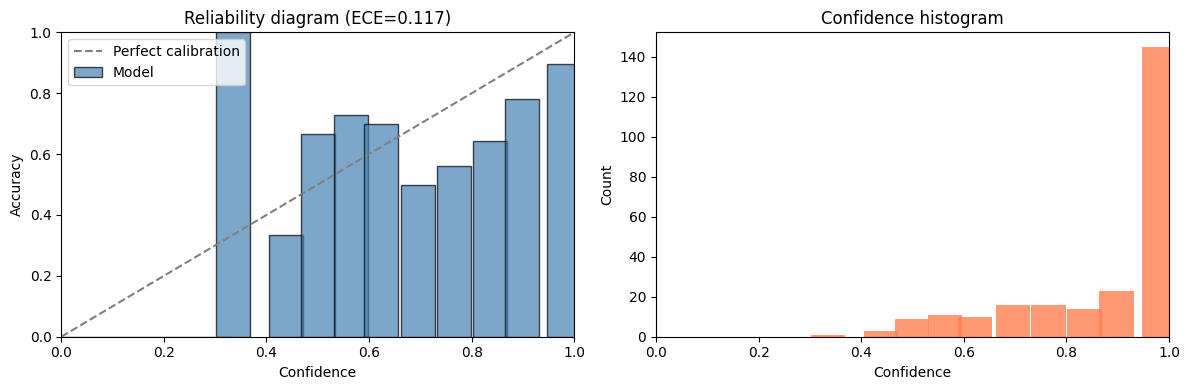

In [19]:
def expected_calibration_error(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = (predictions == labels).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_confs, bin_accs, bin_counts = [], [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        n = mask.sum()
        if n > 0:
            conf_in_bin = confidences[mask].mean()
            acc_in_bin  = accuracies[mask].mean()
            ece += (n / len(confidences)) * abs(conf_in_bin - acc_in_bin)
            bin_confs.append(conf_in_bin)
            bin_accs.append(acc_in_bin)
            bin_counts.append(n)
        else:
            bin_confs.append((lo + hi) / 2)
            bin_accs.append(0.0)
            bin_counts.append(0)
    return ece, np.array(bin_confs), np.array(bin_accs), np.array(bin_counts)


ece, bin_confs, bin_accs, bin_counts = expected_calibration_error(
    all_probs, np.array(all_true), n_bins=15)
print(f'Expected Calibration Error (ECE, 15 bins): {ece:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# reliability diagram
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
axes[0].bar(bin_confs, bin_accs, width=1/15, edgecolor='black',
            color='steelblue', alpha=0.7, align='center', label='Model')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Reliability diagram (ECE={ece:.3f})')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend()

# confidence histogram
axes[1].bar(bin_confs, bin_counts, width=1/15, color='coral', alpha=0.8, align='center')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence histogram')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


## Uncertainty-guided triage
Uncertain predictions can be flagged for review; if removed itshould increase accuracy on the remaining cases.

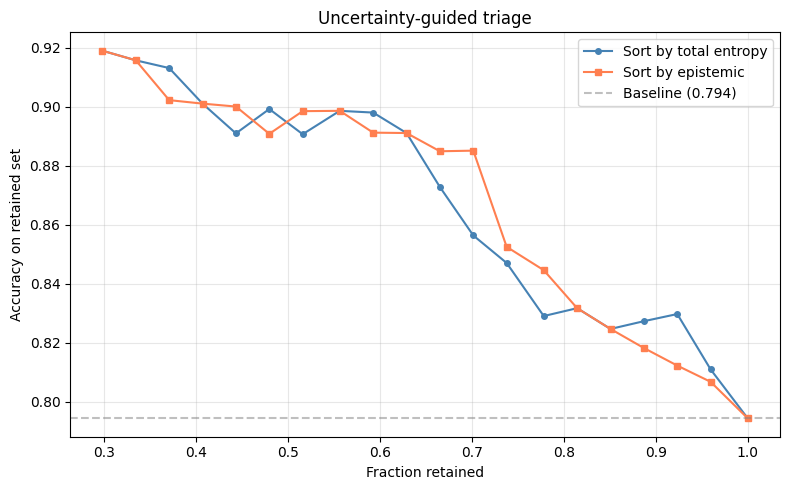

Accuracy on top 50% most confident (total entropy):  0.8871
Accuracy on top 50% most confident (epistemic only): 0.8952


In [20]:
def triage_curve(df, uncertainty_col='entropy', steps=20):
    """Accuracy vs fraction retained after removing most uncertain cases."""
    sorted_df = df.sort_values(uncertainty_col)
    n = len(sorted_df)
    cutoffs = np.linspace(n, int(0.3 * n), steps, dtype=int)
    fractions, accuracies = [], []
    for cutoff in cutoffs:
        retained = sorted_df.iloc[:cutoff]
        fractions.append(cutoff / n)
        accuracies.append(retained['correct'].mean())
    return fractions, accuracies

fractions_tot, accuracies_tot = triage_curve(results_df, 'entropy')
fractions_epi, accuracies_epi = triage_curve(results_df, 'epistemic')
baseline_acc = results_df['correct'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fractions_tot, accuracies_tot, marker='o', markersize=4, color='steelblue', label='Sort by total entropy')
ax.plot(fractions_epi, accuracies_epi, marker='s', markersize=4, color='coral',     label='Sort by epistemic')
ax.axhline(baseline_acc, linestyle='--', alpha=0.5, color='grey', label=f'Baseline ({baseline_acc:.3f})')
ax.set_xlabel('Fraction retained')
ax.set_ylabel('Accuracy on retained set')
ax.set_title('Uncertainty-guided triage')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# accuracy on most confident 50%
top50_ent = results_df.sort_values('entropy').head(int(0.5 * len(results_df)))['correct'].mean()
top50_epi = results_df.sort_values('epistemic').head(int(0.5 * len(results_df)))['correct'].mean()
print(f'Accuracy on top 50% most confident (total entropy):  {top50_ent:.4f}')
print(f'Accuracy on top 50% most confident (epistemic only): {top50_epi:.4f}')


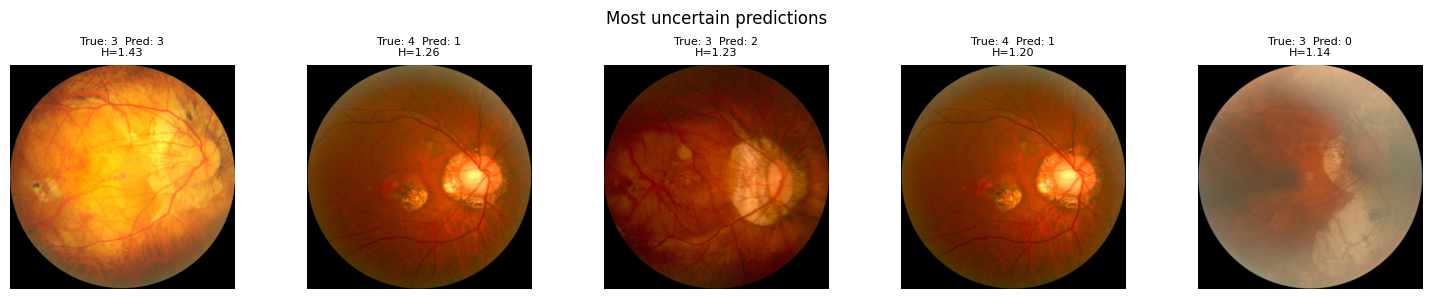

In [21]:
# Display the 5 most uncertain test images
top_uncertain = results_df.sort_values("entropy", ascending=False).head(5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (_, row) in zip(axes, top_uncertain.iterrows()):
    img_path = os.path.join(test_images_folder, row["image_name"])
    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(f"True: {int(row['true_label'])}  Pred: {int(row['pred_label'])}\n"
        f"H={row['entropy']:.2f}", fontsize=8 )
    ax.axis("off")

plt.suptitle("Most uncertain predictions", fontsize=12)
plt.tight_layout()
plt.show()


In [22]:
# Save full uncertainty results for use in comparative evaluation
results_df.to_csv("Task5_uncertainty_results.csv", index=False)
print("Results saved to Task5_uncertainty_results.csv")


Results saved to Task5_uncertainty_results.csv
